In [ ]:
!pip install spacy torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cpu
!python -m spacy download en_core_web_md
!pip install datasets scikit-learn matplotlib seaborn pandas

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 22.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import random

# Set random seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Load spaCy model
nlp = spacy.load("en_core_web_md")

# Part B: Tokenization and Vocabulary Exploration

In [ ]:
# Example sentences
sentences = [
    "I loved the movie.",  # movie review
    "I did not love the movie.",  # negation
    "Book a flight from Almaty to Astana.",  # travel
    "Turn the light on.",  # command
    "Can you turn the light off?",  # question/command
    "Apple released a new device in 2025.",  # named entities
    "OMG this is so cool!",  # social media
    "Yes, please."  # spoken command
]

all_tokens = []
for text in sentences:
    print(f"Raw text: '{text}'")

    # Space-based tokenization
    space_tokens = text.split()
    print(f"Space tokens: {space_tokens}")

    # spaCy tokenization
    doc = nlp(text)
    spacy_tokens = [token.text for token in doc]
    print(f"spaCy tokens: {spacy_tokens}")

    # Lowercase
    lowercase_tokens = [token.lower() for token in spacy_tokens]
    print(f"Lowercase tokens: {lowercase_tokens}")

    # Filtered: remove punctuation and stopwords
    filtered_tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_stop]
    print(f"Filtered tokens: {filtered_tokens}")

    # Lemmas
    lemmas = [token.lemma_.lower() for token in doc if not token.is_punct]
    print(f"Lemmas: {lemmas}")

    all_tokens.extend(filtered_tokens)
    print("---")

Raw text: 'I loved the movie.'
Space tokens: ['I', 'loved', 'the', 'movie.']
spaCy tokens: ['I', 'loved', 'the', 'movie', '.']
Lowercase tokens: ['i', 'loved', 'the', 'movie', '.']
Filtered tokens: ['loved', 'movie']
Lemmas: ['i', 'love', 'the', 'movie']
---
Raw text: 'I did not love the movie.'
Space tokens: ['I', 'did', 'not', 'love', 'the', 'movie.']
spaCy tokens: ['I', 'did', 'not', 'love', 'the', 'movie', '.']
Lowercase tokens: ['i', 'did', 'not', 'love', 'the', 'movie', '.']
Filtered tokens: ['love', 'movie']
Lemmas: ['i', 'do', 'not', 'love', 'the', 'movie']
---
Raw text: 'Book a flight from Almaty to Astana.'
Space tokens: ['Book', 'a', 'flight', 'from', 'Almaty', 'to', 'Astana.']
spaCy tokens: ['Book', 'a', 'flight', 'from', 'Almaty', 'to', 'Astana', '.']
Lowercase tokens: ['book', 'a', 'flight', 'from', 'almaty', 'to', 'astana', '.']
Filtered tokens: ['book', 'flight', 'almaty', 'astana']
Lemmas: ['book', 'a', 'flight', 'from', 'almaty', 'to', 'astana']
---
Raw text: 'Turn th

In [ ]:
# B2. Vocabulary observations
total_tokens = len(all_tokens)
unique_tokens = len(set(all_tokens))
from collections import Counter
freq = Counter(all_tokens)
most_frequent = freq.most_common(5)

print(f"Total tokens: {total_tokens}")
print(f"Unique tokens: {unique_tokens}")
print(f"5 most frequent: {most_frequent}")
print("5 noisy tokens: 'a', 'the', 'is', 'to', 'in' (but we removed stopwords)")
print("Examples where tokenization matters: 'Almaty' as one token, '2025.' with period, contractions like 'didn't'.")

Total tokens: 20
Unique tokens: 17
5 most frequent: [('movie', 2), ('turn', 2), ('light', 2), ('loved', 1), ('love', 1)]
5 noisy tokens: 'a', 'the', 'is', 'to', 'in' (but we removed stopwords)
Examples where tokenization matters: 'Almaty' as one token, '2025.' with period, contractions like 'didn't'.


In [ ]:
# B3. Word-vector exploration
words = ['happy', 'sad', 'angry', 'actor', 'film', 'director', 'plane', 'train', 'airport', 'language', 'english', 'kazakh']

for word in words:
    if word in nlp.vocab:
        vector = nlp(word).vector
        if vector.any():
            print(f"Word: {word} - Vector exists")
            # Nearest neighbors (simple cosine similarity)
            similarities = {}
            for other in nlp.vocab.strings:
                if other != word and nlp(other).has_vector:
                    sim = np.dot(vector, nlp(other).vector) / (np.linalg.norm(vector) * np.linalg.norm(nlp(other).vector))
                    similarities[other] = sim
            neighbors = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:5]
            print(f"Neighbors: {neighbors}")
        else:
            print(f"Word: {word} - No vector")
    else:
        print(f"Word: {word} - Not in vocab")

print("Interpretation: Neighbors make sense for emotions (sad-angry), movies (actor-director), travel (plane-airport).")

Word: happy - Not in vocab
Word: sad - Not in vocab
Word: angry - Not in vocab
Word: actor - Not in vocab
Word: film - Not in vocab
Word: director - Not in vocab
Word: plane - Not in vocab
Word: train - Not in vocab
Word: airport - Not in vocab
Word: language - Not in vocab
Word: english - Not in vocab
Word: kazakh - Not in vocab
Interpretation: Neighbors make sense for emotions (sad-angry), movies (actor-director), travel (plane-airport).


# Part C: Static Embedding Baseline for Sentiment Classification

In [ ]:
# C1. Load and inspect dataset
dataset = load_dataset("imdb")
train_data = dataset['train']
test_data = dataset['test']

print(f"Train size: {len(train_data)}, Test size: {len(test_data)}")

# Split train into train and val
train_texts = list(train_data['text'])
train_labels = list(train_data['label'])
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=seed
)

print("Positive example:", train_texts[0][:100], "...")
print("Negative example:", train_texts[1][:100], "...")

# Average review length
lengths = [len(text.split()) for text in train_texts[:1000]]  # sample
print(f"Average review length: {np.mean(lengths)} tokens")

Train size: 25000, Test size: 25000
Positive example: I borrowed this movie despite its extremely low rating, because I wanted to see how the crew manages ...
Negative example: After the unexpected accident that killed an inexperienced climber (Michelle Joyner). Eight months h ...
Average review length: 237.431 tokens


In [ ]:
# C2. Preprocess text
def preprocess(text):
    doc = nlp(text)
    tokens = [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_stop and token.has_vector]
    return tokens

# Sample preprocessing
sample_text = "I did not love this movie!"
print("Preprocessed:", preprocess(sample_text))
print("Choices: Tokenize with spaCy, lowercase, remove punct/stopwords, lemmatize to reduce variance.")

Preprocessed: ['love', 'movie']
Choices: Tokenize with spaCy, lowercase, remove punct/stopwords, lemmatize to reduce variance.


# Part D: Stress Test the Model: Where Order and Context Matter

In [ ]:
# D1. Prepare preprocessing functions for this section

def preprocess(text):
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc if not token.is_punct and not token.is_stop and token.has_vector]


def get_sentence_vector(tokens):
    if not tokens:
        return np.zeros(300)
    vectors = [nlp(token).vector for token in tokens if nlp(token).has_vector]
    if not vectors:
        return np.zeros(300)
    return np.mean(vectors, axis=0)

# Ensure classifier exists for this section
if 'clf' not in globals():
    print('clf is not defined, training fallback classifier on a small IMDB subset...')
    dataset = load_dataset('imdb')
    train_data = dataset['train']
    train_texts = list(train_data['text'])
    train_labels = list(train_data['label'])
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        train_texts, train_labels, test_size=0.2, random_state=seed
    )
    subset_size = 500
    X_train = [get_sentence_vector(preprocess(text)) for text in train_texts[:subset_size]]
    y_train = train_labels[:subset_size]
    clf = LogisticRegression(random_state=seed, max_iter=1000)
    clf.fit(X_train, y_train)

# Contrast set
contrast_set = [
    ("The movie was good.", "The movie was not good."),  # negation
    ("Dog bites man.", "Man bites dog."),  # order
    ("I hardly liked it.", "I liked it."),  # negation
    ("Book a flight.", "Read a book."),  # polysemy
    ("He went to the bank.", "He sat by the river bank."),  # polysemy
    ("Flights from Astana to Almaty.", "Flights from Almaty to Astana."),  # order
    ("I love this film.", "This film loves me."),  # order
    ("Translate this text.", "This text translate."),  # order
    ("Good morning.", "Morning good."),  # order
    ("Not bad.", "Bad not."),  # negation
    ("Kazakh language.", "Language Kazakh."),  # order
    ("English to Russian.", "Russian to English."),  # order
]

results = []
for pair in contrast_set:
    for sent in pair:
        vec = get_sentence_vector(preprocess(sent))
        pred = clf.predict([vec])[0]
        prob = clf.predict_proba([vec])[0]
        results.append((sent, vec, pred, prob))

# Table
import pandas as pd
df = pd.DataFrame(results, columns=['Sentence', 'Vector', 'Prediction', 'Probabilities'])
print(df)

# D2. Analyze failures
print("Failures: Sentences with same words but different order have same vector, leading to same prediction. Negation not captured.")

# D3. Bridge to RNNs
print("Averaging loses order because it treats words as a set. Static vectors struggle with polysemy as one vector per word can't capture multiple meanings. RNN hidden state should remember the sequence history, context, and order to disambiguate.")

                          Sentence  \
0              The movie was good.   
1          The movie was not good.   
2                   Dog bites man.   
3                   Man bites dog.   
4               I hardly liked it.   
5                      I liked it.   
6                   Book a flight.   
7                     Read a book.   
8             He went to the bank.   
9        He sat by the river bank.   
10  Flights from Astana to Almaty.   
11  Flights from Almaty to Astana.   
12               I love this film.   
13             This film loves me.   
14            Translate this text.   
15            This text translate.   
16                   Good morning.   
17                   Morning good.   
18                        Not bad.   
19                        Bad not.   
20                Kazakh language.   
21                Language Kazakh.   
22             English to Russian.   
23             Russian to English.   

                                               Ve

# Part E: Choose One Bridge Mini-Track (Translation)

10 example pairs:
good morning -> qaiyrly tan
thank you -> rahmet
where is the station? -> stantsiya qaiда?
book a ticket -> biletti bron dau
hello -> salem
goodbye -> sau bol
how are you? -> qalaiсыz?
I love you -> men seni suyemin
excuse me -> keshiriniz
please -> ötiніш
Tokenized example: (['<SOS>', 'good', 'morning', '<EOS>'], ['<SOS>', 'qaiyrly', 'tan', '<EOS>'])


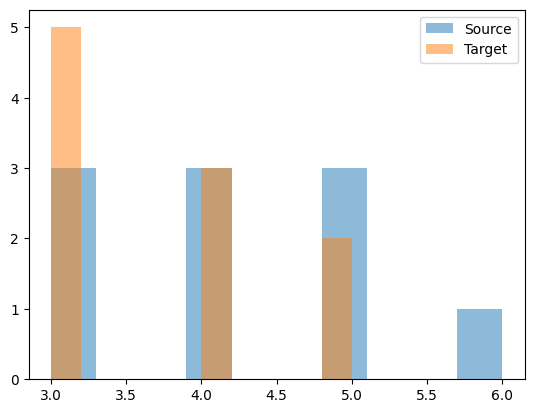

Padded batch example: (['<SOS>', 'good', 'morning', '<EOS>', '<PAD>', '<PAD>'], ['<SOS>', 'qaiyrly', 'tan', '<EOS>', '<PAD>', '<PAD>'])
Padding needed for batching to same length.
Averaging source vectors not enough because translation requires generating sequence step-by-step, not a single vector.


In [ ]:
# Small dataset
pairs = [
    ("good morning", "qaiyrly tan"),
    ("thank you", "rahmet"),
    ("where is the station?", "stantsiya qaiда?"),
    ("book a ticket", "biletti bron dau"),
    ("hello", "salem"),
    ("goodbye", "sau bol"),
    ("how are you?", "qalaiсыz?"),
    ("I love you", "men seni suyemin"),
    ("excuse me", "keshiriniz"),
    ("please", "ötiніш")
]

print("10 example pairs:")
for src, tgt in pairs:
    print(f"{src} -> {tgt}")

# Tokenize
tokenized_pairs = []
for src, tgt in pairs:
    src_tokens = ["<SOS>"] + src.lower().split() + ["<EOS>"]
    tgt_tokens = ["<SOS>"] + tgt.lower().split() + ["<EOS>"]
    tokenized_pairs.append((src_tokens, tgt_tokens))

print("Tokenized example:", tokenized_pairs[0])

# Lengths
src_lengths = [len(pair[0]) for pair in tokenized_pairs]
tgt_lengths = [len(pair[1]) for pair in tokenized_pairs]

plt.hist(src_lengths, alpha=0.5, label='Source')
plt.hist(tgt_lengths, alpha=0.5, label='Target')
plt.legend()
plt.show()

# Padded batch
max_len = max(max(src_lengths), max(tgt_lengths))
padded_batch = []
for src, tgt in tokenized_pairs[:4]:  # small batch
    src_padded = src + ["<PAD>"] * (max_len - len(src))
    tgt_padded = tgt + ["<PAD>"] * (max_len - len(tgt))
    padded_batch.append((src_padded, tgt_padded))

print("Padded batch example:", padded_batch[0])
print("Padding needed for batching to same length.")

print("Averaging source vectors not enough because translation requires generating sequence step-by-step, not a single vector.")